## Prédiction du prix des billets d'avion

L'objectif de ce projet est de predire **le prix des billets d'avion** en fonction de diverses caracteristiques telles que la **date de réservation**, **la durée du vol**,**le nombre d'escales**, etc.   
Nous allons mener des anlyses de données pour comprendres les relations entre les diffrentes variables et le prix des billets. Ensuite construire un modele prédictif pour estimer le prix des billets en fonction des caracteristique disponibles.  

L'objectif est d'être capable de predire le prix des billets d'avion avec un erreur moyenne raisonnable.  

### Sommaire

* **Les données**
* **Analyse technique** 
   * **Analyse univariée** 
   * **Analyse multivarié** 
* **Formuler et tester des hypothse** 
* **Préprocessing**
* **Modelisation** 
* **Eavluation finale du modèle**

## Import 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, KFold


Analyse fondammenatale  
Le Dataset provient de kaggle, et est disponible [ici](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction), c'est le dataset Clean_Dataset.csv  
**Quoi** :Un dataset de 300 261 reservation de vols distinctes, extrait d’un site web, couvrant des vols programmés entre les plus grandes villes.  
**Quand** : Données collecté sur une periode de 50 jours, du 11 fevrier au 31 decembre mars 2022  
**Ou**: Les données proviennent du site web Ease my trip  
**Comment** : Scrapping avec l'outils Octoparse. Les données ont été collecté en deux parties : une pour les billets de classe économique et l'autre   pour les billets de classe affairres.  

In [2]:
path = Path().resolve().parent/"data"/"Clean_Dataset.csv"
df_original = pd.read_csv(path)
df_original.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Analyse technique du jeu de données 

Cette étape sert à determiner ce qui est faisable en analyse univariée et multivariée 
l'objectif est double :
   1. **Identifie le type de chaque variable**  
    - Variable discrete   
    - Variable continue 
    - Date ? Texte libre 
    - Fausses quantités ? (ex: durée exprime enn string)

   2. **Identifier ce que l'on peut faire avec chacune d'elles** 
   -> Est-ce qu'on peut calculer des Statistiques   
   -> Est-ce qu'on peut comparer des categories ?  
   -> Est-ce qu'on doit transformer des colonnes avant toutes analyse ?  

#### Classification des variables (Discrete /continue/autre)

* **airline**        -> Discrete(Catégorielle)   
* **flight**         -> Discrete(Catégorielle)   
* **source_city**    -> Discrete(Catégorielle) 
* **departure_time** -> Discrete(catégorielle Ordinale) 
* **stops**          -> Discrete(Nuemerique Ordinale) 
* **arrival_time**   -> Discrete(catégorielle Ordinale) 
* **destination_city**-> Discrete(Catégorielle) 
* **class**          -> Discrete(Ordinale) 
* **duration**  -> Continue(numérique)
* **days_left**	-> Continue(numérique)
* **price**     -> Continue(numérique) variable cible


In [3]:
discrete_cols = ["airline", "flight", "source_city","departure_time", "stops", "arrival_time","destination_city", "class" ]
continues_cols = ["duration", "days_left", "price"]


In [4]:
# Comptage rapide des Catégories pour les variables discrètes  
for col in discrete_cols:
    print(f"\n---{col}--")
    print(df_original[col].value_counts().head())


---airline--
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
Name: count, dtype: int64

---flight--
flight
UK-706    3235
UK-772    2741
UK-720    2650
UK-836    2542
UK-822    2468
Name: count, dtype: int64

---source_city--
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Name: count, dtype: int64

---departure_time--
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Name: count, dtype: int64

---stops--
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

---arrival_time--
arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Name: count, dtype: int64

---destination_city--
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyde

### Analyse Univariée 
Maintenant que les variables ont été classé, on commence l'analyse statistique variable par variable. 

L'objectif est ici :

* Pour les variables discretes : on liste les effectifs et visualise les catégories majoritaires/minoritaires.
* Pour les variables continues : voir la distribution, les valeurs extrêmes, les asymetries, etc. 

In [ ]:
import sys
sys.path.append('..')
from src.visualisation import univ_analysis_discrete, univ_analysis_continue

#### Price
Analyse de la variable cible


/----price----/


count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

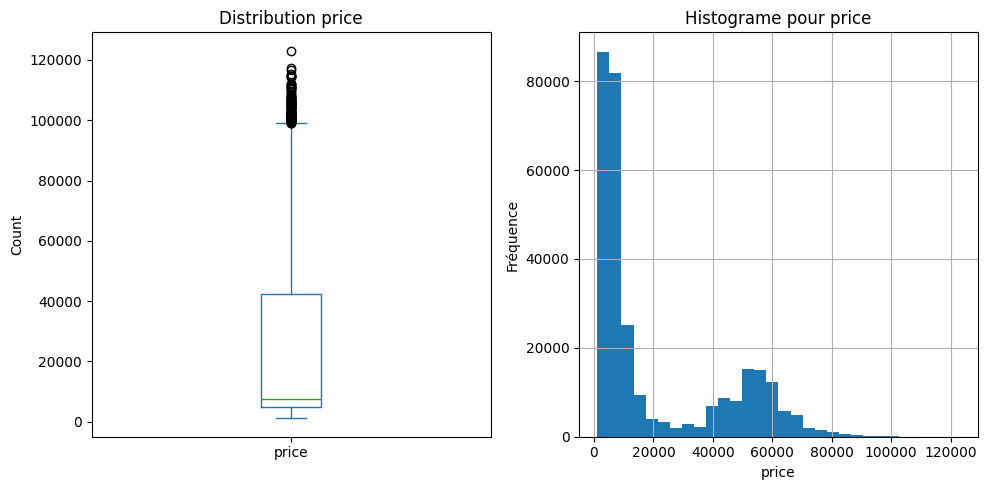

In [6]:
univ_analysis_continue(df_original,"price")

* La moyenne du prix est 20889 Roupie, mais la mediane est à 7425 Roupie, ce qui indique une distribution asymetrique avec une longue queue à droite (quelques billets très chers). C'est ce qu'on observe dans l'histogramme.
* Les deux groupes de prix correspondens en fait aux classes économique et business 

#### Airline


====airline===
count      300153
unique          6
top       Vistara
freq       127859
Name: airline, dtype: object


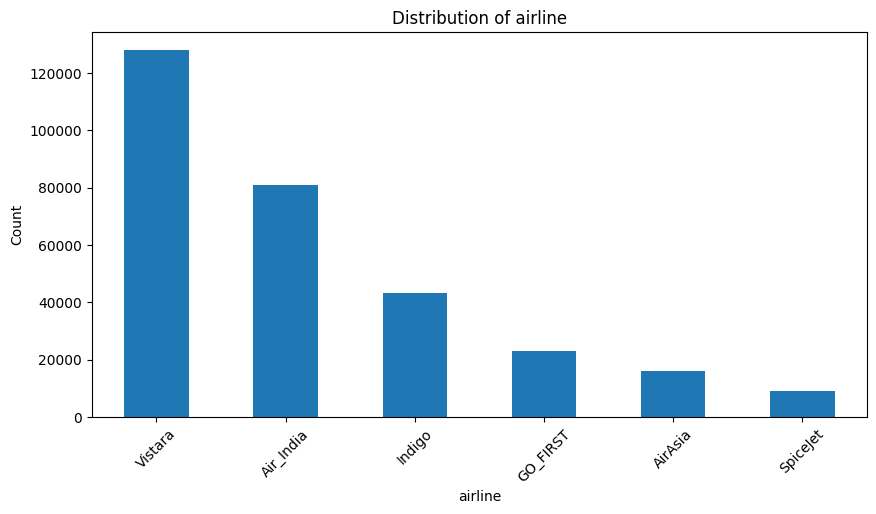

In [7]:
univ_analysis_discrete(df_original, 'airline')

* Nous constatons la compagnie Vistara est dominante dans notre jeu de données  
* Variable discrete à forte part de marché inégale.
* Impact probable sur le prix ->

#### Source_city


====source_city===
count     300153
unique         6
top        Delhi
freq       61343
Name: source_city, dtype: object


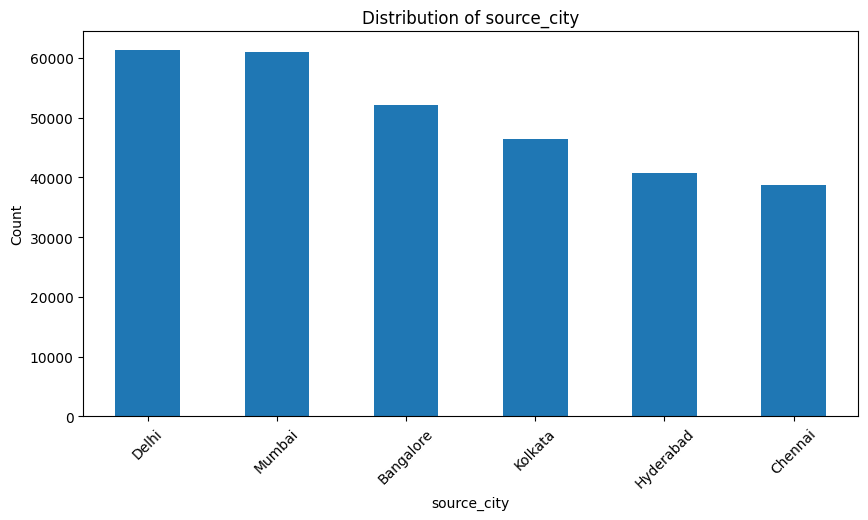

In [8]:
univ_analysis_discrete(df_original,"source_city")

#### Departure_time


====departure_time===
count      300153
unique          6
top       Morning
freq        71146
Name: departure_time, dtype: object


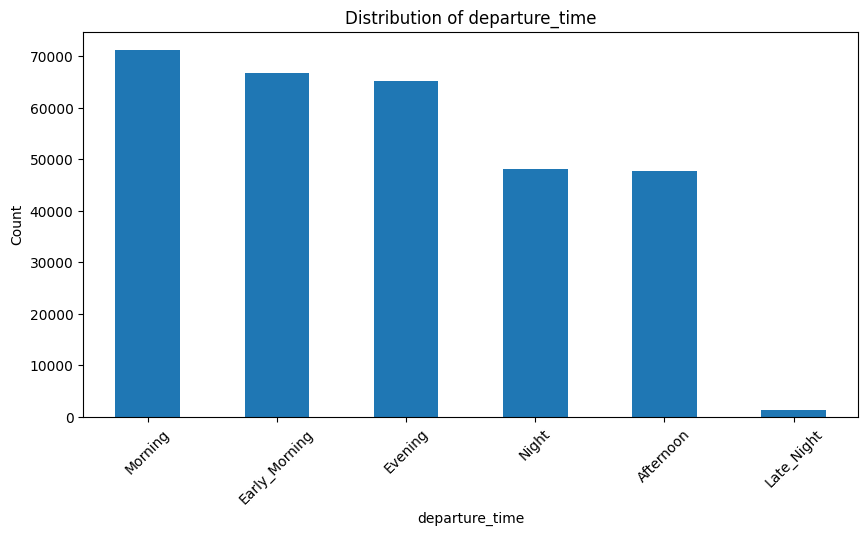

In [9]:
univ_analysis_discrete(df_original,"departure_time")

Trés peu de vol tardive

#### Stops

In [10]:
def vi():
 display(df_original["airline"].value_counts())
vi()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


====stops===
count     300153
unique         3
top          one
freq      250863
Name: stops, dtype: object


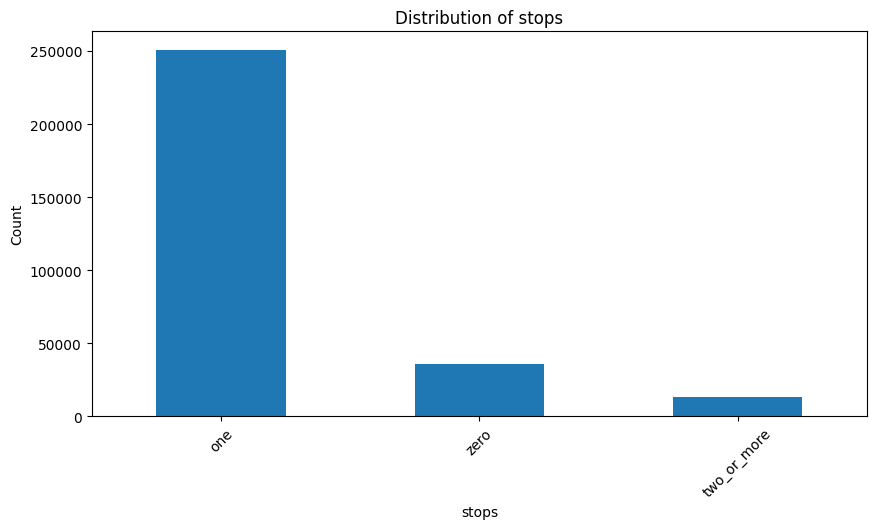

In [11]:
univ_analysis_discrete(df_original,"stops")

La plupart des vols font un escale

Le temps d'arrivé


====arrival_time===
count     300153
unique         6
top        Night
freq       91538
Name: arrival_time, dtype: object


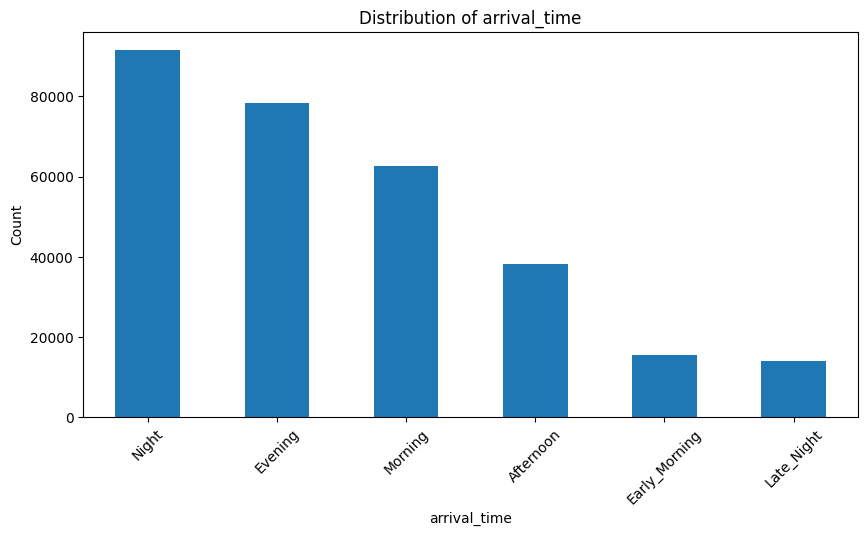

In [12]:
univ_analysis_discrete(df_original, 'arrival_time')

Beaucoup de vol arrive tard la nuit 

#### L'aeroport d'arrivé


====destination_city===
count     300153
unique         6
top       Mumbai
freq       59097
Name: destination_city, dtype: object


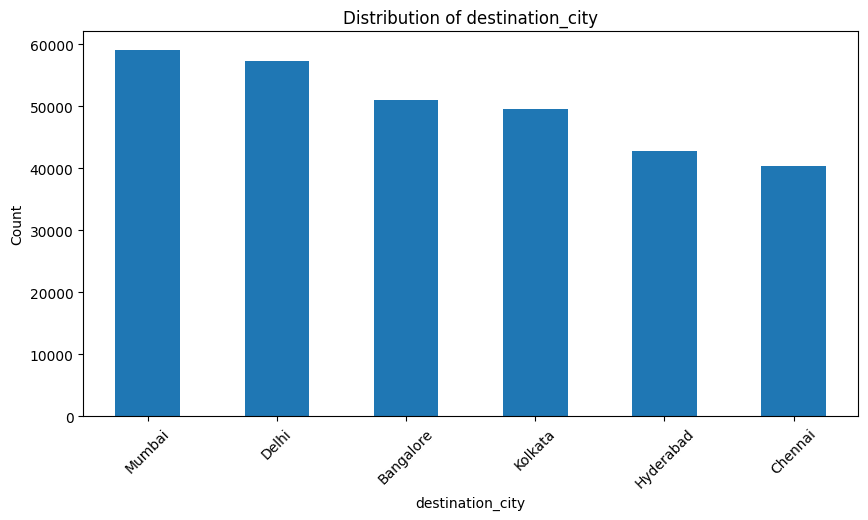

In [13]:
univ_analysis_discrete(df_original, "destination_city")

#### Class 


====class===
count      300153
unique          2
top       Economy
freq       206666
Name: class, dtype: object


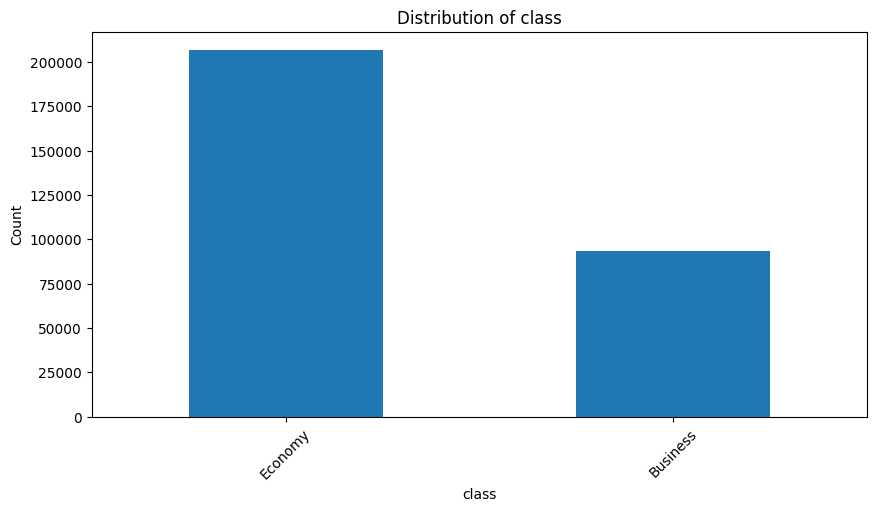

In [14]:
univ_analysis_discrete(df_original, "class")

A peu près deux fois plus de billet en classe économique qu'en classe business.

#### Duration 


/----duration----/


count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64

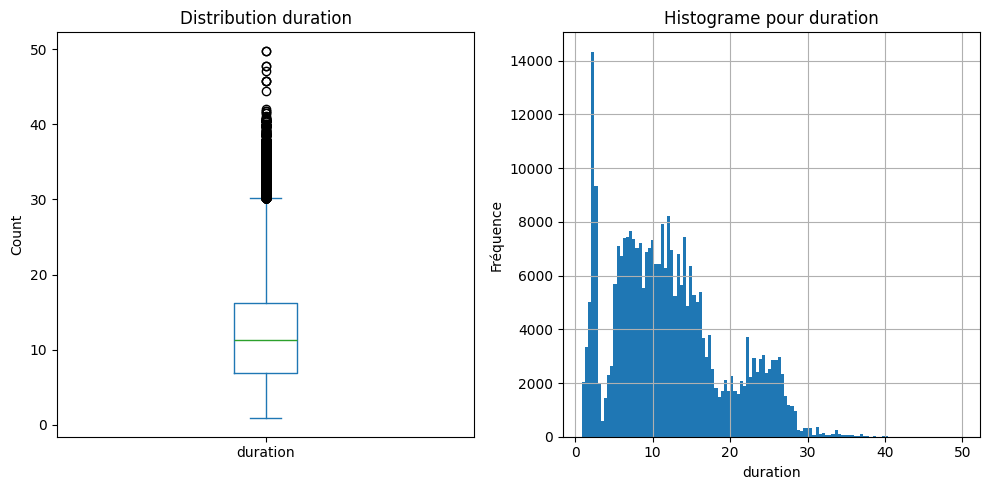

In [15]:
univ_analysis_continue(df_original, "duration", nbins=120)

### Analyse multivariée 

##### a. Relation entre le prix et la durée du vol

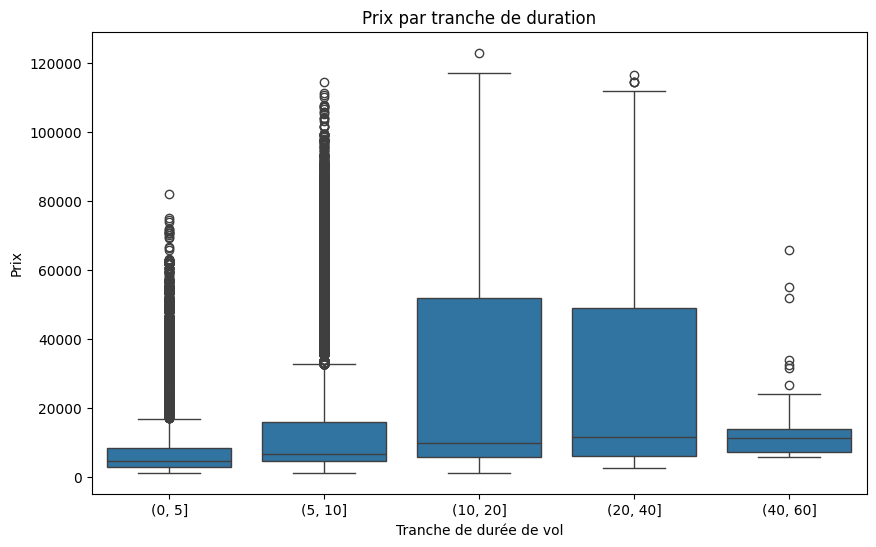

In [16]:
df_original["duration_bin"] = pd.cut(df_original["duration"], bins=[0,5,10,20,40,60])

plt.figure(figsize=(10,6))
sns.boxplot(x="duration_bin", y="price", data=df_original)
plt.title("Prix par tranche de duration")
plt.xlabel("Tranche de durée de vol")
plt.ylabel("Prix")
plt.show()

On remarque que les prix moyens semblent varier positivement avec la durée du vol.

#### b. Relation entre le prix et la compagnie aerienne 

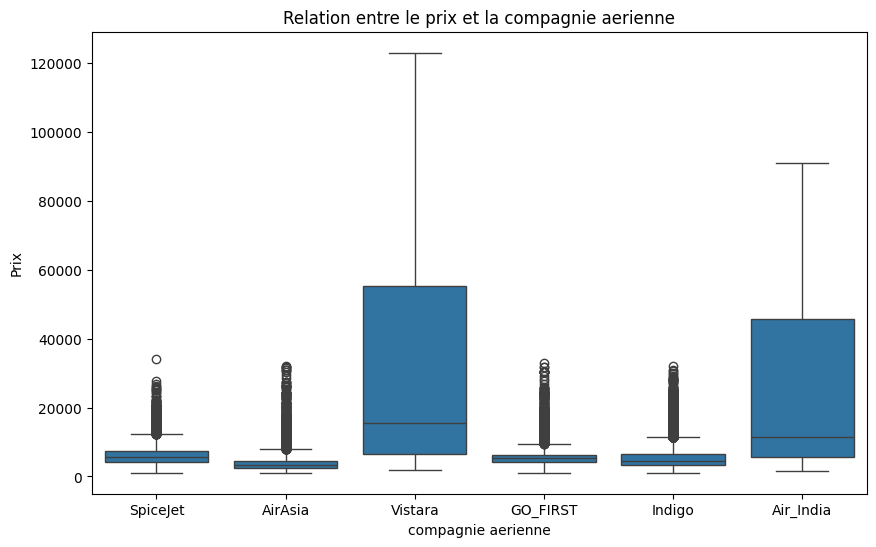

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x="airline", y="price", data=df_original)
plt.title("Relation entre le prix et la compagnie aerienne")
plt.xlabel("compagnie aerienne")
plt.ylabel("Prix")
plt.show()

On remarque que pour certaines compagnie comme **Vistara et air india** le prix de billet relativement être plus élévé que les autre compagnie, donc nous pouvons mettre un hypothèse que la compagnie aerienne semble avoir un impact significatif sur le prix de billet 

#### c. Relation entre le nombre d'escale et le prix

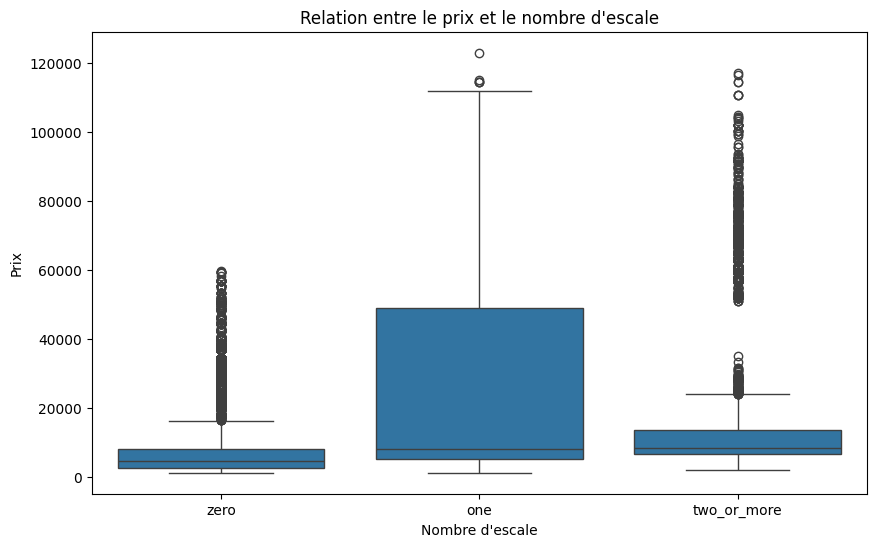

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x="stops", y="price", data=df_original)
plt.title("Relation entre le prix et le nombre d'escale")
plt.xlabel("Nombre d'escale")
plt.ylabel("Prix")
plt.show()

En moyenne, le prix est plus élévé pour les vols avec au moins un escale. Cependant, il y'a une grade variabilité des prix pour chaque catégorie d'escales, indiquant que d'autre facteur influencent également le prix des billets. 

##### d. Relation entre le nombre de jours entre la reservation et le vol et le prix 

Text(0, 0.5, 'Prix')

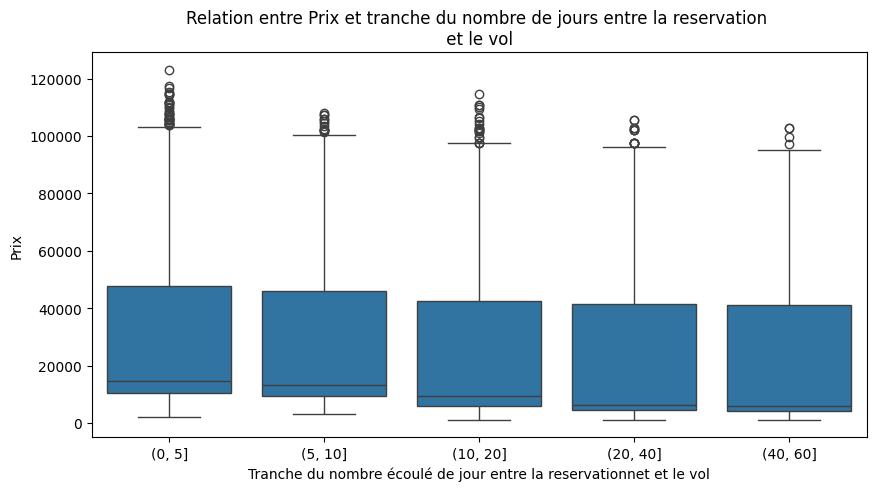

In [19]:
df_original["days_bins"] = pd.cut(df_original["days_left"],bins=[0,5,10,20,40,60])

plt.figure(figsize=(10,5))
sns.boxplot(data=df_original, x="days_bins", y="price")
plt.title("Relation entre Prix et tranche du nombre de jours entre la reservation \n et le vol ")
plt.xlabel("Tranche du nombre écoulé de jour entre la reservationnet et le vol")
plt.ylabel("Prix")


In [20]:
df_original = df_original.drop(columns=["duration_bin", "days_bins"])

En moyenne le prix tend à diminuer avec le nombre de jours entre la reservation et le vol. Reservé tôt semble associé à des prix plus bas. 

### Formuler et test des hypothèses 

Après l'analyse technique, univarié et multivarié, on va formuler des **hypothèse statistique et les tester**. L'idée est pertir de nos observation précedentes et de les transformer en hypothèse, que l'on va ensuite valider ou non.

In [21]:
alpha = 0.05

A partir des graphiques et des statistiques calculées précedemment, on retient es observations suivantes :  

1. Durée du vol vs Prix

Question : Les vols les plus longs sont-ils associé à des prix plus éléve ?   
On teste l'existence d'une correlation linéaire entre : 
* `duration`(variable continue)
* `price`(variable continue)

**Hypothèse:**
- $H_0$ : la correlation linéaire entre `duration` et `price` est nulle. -> (*La durée du vol n’influence pas le prix*.)
- $H_1$ : la correlation linéaire entre `duration` et `price` est non null.-> (*La durée du vol influence le prix*)

On utilise le **test de personn**

In [22]:
# Test de correlation entre duration et price
corr_duration_price, p_value_duration_price = stats.pearsonr(df_original["duration"], df_original["price"])

print("Correlation (duration, price):", corr_duration_price)
print("p-value:", p_value_duration_price)

if p_value_duration_price < alpha:
    print(f"-> p-value < {alpha} : on rejette H0.")
    print("Conclusion : la durée du vol influence le prix")
    
else:
    print(f"-> p-value > {alpha}: on ne rejette pas H0")
    print("Conclusion: on ne met pas evidence entre le correlationn linéaire significative entre la durée du vol et le prix")

Correlation (duration, price): 0.2042223678454271
p-value: 0.0
-> p-value < 0.05 : on rejette H0.
Conclusion : la durée du vol influence le prix


2. Compagnie aerienne vs Prix
Question : les differentes compagnie pratiquent-elles en moyenne le même niveau de prix ?
- Variable discrete : `airline`
- Variable continue : `Price`

##### Hypothèses : 
- $H_0$ : le prix moyen des billets est le même pour toutes les compagnies.
- $H_1$ : au moins une des compagnies a prix moyen different des autres. 

On utlise un **test d'Anova (f_oneway)**


In [23]:
f_stat_airline, p_value_airline = stats.f_oneway(*df_original.groupby("airline",observed=False)["price"].apply(list))
print("Statistique F(airline vs price):", f_stat_airline)
print("p-value:", p_value_airline)

if p_value_airline < alpha:
    print(f"-> p-value < {alpha}: on rejette H0.")
    print("Conclusion : le prix moyen n'est pas le même pour toutes ces compagnies(aumoins une se distingue)")
else:
    print(f"-> p-value >= {alpha}")
    print("Conclusion : nous n'avons pas de preuve suffisante pour dire que le prix moyen diffère entre ces compagnies")

Statistique F(airline vs price): 17194.402096092366
p-value: 0.0
-> p-value < 0.05: on rejette H0.
Conclusion : le prix moyen n'est pas le même pour toutes ces compagnies(aumoins une se distingue)


##### 3. Nombre d'escales vs Prix

**Question: le prix moyen est-il identique quel que soit le nombre d'escales ?**
* Variable discrète : stops
* Variable continue : price

Hypothèse :
* $H_0$ : le prix moyen des billets est le même pour tous les niveaux d'escales.
* $H_1:$ le prix moyen des buillets dépend du nombre d'escales.

Nous utilise un **test d'anova** 

In [24]:
print("Valeurs de 'stops' : ['One', 'two_or_more', 'zero']")
f_stat_stops_price, p_value_stops_price = stats.f_oneway(*df_original.groupby("stops",observed=False)["price"].apply(list))
print("Statistique F(stops vs price):", f_stat_stops_price)
print("p-value:", p_value_stops_price)

if p_value_stops_price < alpha:
    print(f"-> p-value < {alpha}: on rejette H0.")
    print("Conclusion : le prix moyen depend du nombre d'escales")
else:
    print(f"-> p-value >= {alpha}")
    print("Conclusion : nous n'avons pas de preuve suffisante pour dire le prix moyen des billets dépend du nombre d'escales")

Valeurs de 'stops' : ['One', 'two_or_more', 'zero']
Statistique F(stops vs price): 6477.130362486244
p-value: 0.0
-> p-value < 0.05: on rejette H0.
Conclusion : le prix moyen depend du nombre d'escales


##### 4. Nombre de jours avant le vol vs Prix

**Question** : Réserver plus tôt est-il associé à des prix plus bas ?

- variable continue `days_left`
- variable continue `price`

On utilise un test de personn 

- $H_0$ : il n'existe pas de correlation linéaire entre `days_left` et `price`.
- $H_1$ : il existe une correlation linéaire entre dats_left et price 

In [25]:
# Test la correlation entre le prix et le nombre de jour avant le vol

corr_day_left_price, p_value_day_left_price = stats.pearsonr(df_original["price"], df_original["days_left"])

print("Correlation (duration, price):", corr_day_left_price)
print("p-value:", p_value_day_left_price)

if p_value_day_left_price < alpha:
    print(f"-> p-value < {alpha} : on rejette H0.")
    print("Conclusion : il existe une correlation linéaire significative entre le nombre jours avant le vol et le prix")
    
else:
    print(f"-> p-value > {alpha}: on ne rejette pas H0")
    print("Conclusion: on ne met pas evidence entre le correlationn linéaire significative entre le nombre avant le vol et le prix")

Correlation (duration, price): -0.09194853217143847
p-value: 0.0
-> p-value < 0.05 : on rejette H0.
Conclusion : il existe une correlation linéaire significative entre le nombre jours avant le vol et le prix


## Preprocessing

Après ll'analyse technique, univarié, multivariée, puis les test d'hypthèse, on va maintenant préparer les données pour la modélisation.  
L'objectif du preprocessing est de transformer notre dataset brut en jeu de données exploitable par un modele de machine learning :

* Nettoyer les valeurs aberrantes 
* Encoder les variables catégorielles 
* Créer éventuellement quelques features supplementaire
* Normaliser les variables numériques
* Préparer une pipline scikit-learn reutilisable 

In [26]:
df = df_original.copy()

Encodage simple de `stops` et `class`

* `stops`: variable ordinale(zeros, one, two-or-more) -> 0/1/2
* `class` : Economy / Business -> 0/1

In [27]:
# Encodage original de stops 
mapping_stops = {"zero":0, "one":1, "two_or_more":2}
df["stops_num"] = df["stops"].map(mapping_stops)
print(df[["stops", "stops_num"]].head())

  stops  stops_num
0  zero          0
1  zero          0
2  zero          0
3  zero          0
4  zero          0


In [28]:
# Encodage binaire de class
mapping_class = {"Economy":0, "Business":1}
df["class_num"] = df["class"].map(mapping_class)
print(df[["class", "class_num"]].head())

     class  class_num
0  Economy          0
1  Economy          0
2  Economy          0
3  Economy          0
4  Economy          0


#### Séparation feauture / target et Train/test split

* Target :`price`
* Features : toutes les autres colonnes utiles

On va : 
1. Supprimer la colonne `flight` (identifiant des vols)
2. Supprimer les anciennes Versions catégorielle de `stops` et `class` (on garde les versions numérique).
3. Separer en X(features) et y(target).
4. Faire un `train_test_split` avec 20% des données en test

In [29]:
df_model = df.drop(columns=["flight", "stops","class"])

In [30]:
# Séparation features /target 

X = df_model.drop(columns=["price"])
y = df["price"]

In [31]:
# Train / test split 

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=40)
X_train.shape, X_test.shape

((240122, 10), (60031, 10))

#### Definir les colonnes numérique et catégorielle (Après préprocessing)

On separe les features en deux groupe 
* Features numériques : 
   * `duration`
   * `days_left`
   * `stops_num`
   * `class_num`

Ces variables seront imputées(si besoin) puis standardisées 

* Features catégorielle (nominales , sans ordre):
   * `airline`
   * `source_city`
   * `departure_time`
   * `destination_city`
Ces variables seront encoder en Onehot Encoder 

In [32]:
# Colonnes numériques 
numeric_features = ["duration", "days_left", "stops_num", "class_num"]

In [33]:
# Colonnes catégorielle 
categorical_features = ["airline", "source_city", "departure_time", "destination_city"]

In [34]:
# Pipeline pour les variables numériques : imputation + standardisation
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [35]:
# Pipeline pour les variables catégorielles : Imputer + one-hot encoding 
categocal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("Onehot", OneHotEncoder(drop="first"))
    ]
)

In [36]:
# ColumnTransformer qui applique le bon traitement à chaque type de variable
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categocal_transformer, categorical_features)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [37]:
X_test

,Unnamed: 0,airline,source_city,departure_time,arrival_time,destination_city,duration,days_left,stops_num,class_num
117026,117026,Air_India,Bangalore,Evening,Early_Morning,Chennai,13.17,20,1,0
11819,11819,Air_India,Delhi,Afternoon,Morning,Bangalore,20.67,11,1,0
59836,59836,Vistara,Mumbai,Morning,Night,Bangalore,13.92,40,1,0
34421,34421,Vistara,Delhi,Morning,Night,Hyderabad,10.58,43,1,0
62674,62674,Air_India,Mumbai,Early_Morning,Morning,Kolkata,2.67,9,0,0
...,...,...,...,...,...,...,...,...,...,...
38045,38045,GO_FIRST,Delhi,Evening,Late_Night,Chennai,8.17,20,1,0
104189,104189,Vistara,Bangalore,Morning,Evening,Kolkata,8.08,12,2,0
79476,79476,Vistara,Mumbai,Morning,Night,Chennai,11.50,17,1,0
227119,227119,Vistara,Mumbai,Afternoon,Night,Delhi,6.42,22,1,1


### Préprocesseur prêt pour la modelisation 
L'objet `preprocessor` contient désormais toute la logique de preprocessing :
1. **Nettoyage** (via les imputers)
2. **Encodage** des variables catégorielles (One-hot)
3. **Normalisation** des variables numériques(Standardisation)


### Modelisation 

* Strategie 
  - Famille de probleme -> Régression 
  - On va tester plusieurs modèles 
  - On gardera le meilleur avec une cross-validation sur le train-set

Nous avons maintenant :
* une cible `price`(variable continue)
* un jeu de features prétraitées (via l'objet `preprocessor`)
* une séparation train/test `X_train`, `X_test`, `y_train`, `y_test`.
Nous somme dans un cadre d'apprentissage suppervisé pour un problème de regression.

Nous allons : 
1. Contruire une **baseline** avec un modele naif (DummyRegressor)
2. Entrainer une **régression linéaire**(LinearRegression)
3. Ajouter une **régression Ridge** (modele reguraliser)
4. Tester un modele **Non lineaire**(RandomForestRegressor)
5. Comparer les performance de tous ces modèles 
6. Illustrer le reglage **d'hyperparametre** avec `GridsearchCV`

In [38]:
def evaluate_model(
    name, 
    model, 
    X_train,
    y_train,
    X_test,
    y_test,
    results_dict,
    cv = 5,
    
):
    """
    Evaluer le modele avec validation croisée sur le train, puis refait sur tout le train et évaluer une fois sur le test.
    
    Paramètre
    ---------
    name : str
        Nom du model (pour l'affichage et le dictionnaire de résultats).
    model : estimator /Pipeline
        Modèle ou Pipeline scikit-learn (déjà construit).
    X_train, y_train : array-like
        Données d'entrainement, 
    X_test, y_test : array-like
        Données de test.
    results_dict :dict
        Dictionnaire dans lequel on stock les resultats.
    cv : int
        Nombre de folds pour la validation croisée. 
    """
    # ----- 1) Validation croisée sur le train -----
    
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=KFold(n_splits=cv, shuffle=True, random_state=42),
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
    )
    cv_mae_mean = -cv_results["test_mae"].mean()
    cv_mae_std = cv_results["test_mae"].std()
    
    cv_rmse_mean = -cv_results["test_rmse"].mean()
    cv_rmse_std = cv_results["test_rmse"].std()
    
    cv_r2_mean = cv_results["test_r2"].mean()
    cv_r2_std = cv_results["test_r2"].std()
    
    print(f"==={name}===")
    print(f"Validation croisée ({cv}-fold) sur le train :")
    print(f" MAE (mean ± std ) : {cv_mae_mean:.2f} ± {cv_mae_std:.2f}")
    print(f" RMSE (mean ± std ) : {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}")
    print(f" R² (mean ± std ) : {cv_r2_mean:.4f} ± {cv_r2_std:.4f}")
    
    # # -----2) Refit sur tout le train ----
    # model.fit(X_train, y_train)
    
    # # -----3) Evaluation final sur le test -----
    # y_test_pred = model.predict(X_test)
    
    # test_mae = mean_absolute_error(y_test, y_test_pred)
    # test_rmse = root_mean_squared_error(y_test, y_test_pred)
    # test_r2 = r2_score(y_test, y_test_pred)
    
    # print("Evaluation finale sur le test:")
    # print(f"  Test MAE  : {test_mae:.2f}")
    # print(f"  Test RMSE :{test_rmse:.2f}")
    # print(f"  Test R²   : {test_r2:.4f}")
    # print()
    
    results_dict[name] = {
        "cv_mae_mean": cv_mae_mean,
        "cv_mae_std" : cv_mae_std,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std" : cv_rmse_std,
        "cv_r2_mean"  : cv_r2_mean,
        "cv_r2_std"   : cv_r2_std  
    }

In [39]:
# Distionnaire pour stocker les resultats de tous les modeles
results = {}

#### 1. Baseline DummyRegressor
Nous commencer par une **baseline naive** avant d'entrainer de vrai modele de Machine learning

On utilise ici un DummyRegressor qui predit toujours *la moyenne des prix* observés sur le jeu d'entrainement.

Ce modele : 
* ne regarde pas les features,
* sert uniquement de **référence**: ***un bon modele de doit faire mieux que lui***

In [40]:
dummy_model = DummyRegressor(strategy="mean")
evaluate_model(
    name="DummyRegressor (mean)",
    model= dummy_model,
    X_train = X_train,
    y_train = y_train,
    X_test = X_test,
    y_test = y_test,
    results_dict = results 
)

===DummyRegressor (mean)===
Validation croisée (5-fold) sur le train :
 MAE (mean ± std ) : 19732.72 ± 25.55
 RMSE (mean ± std ) : 22668.11 ± 43.85
 R² (mean ± std ) : -0.0000 ± 0.0000


#### 2. Régression linéaire `LinearRegression`

Nous testons maintenant un vrai modèle de machine learning **la regresion linéaire**  
pour l'utiliser avec nos données :
* On intègre le **preprocessing** (encodage + normalisation) dans une **Pipeline**
* On ajoute ensuite un estimateur `LinearRegression`.

La `Pipeline` permet de :
* fit le préprocesseur uniquement sur le train,
* appliquer exactement les mêmes transformations sur le **test**,
* éviter les fuites de données (date leakage).


In [41]:
linreg_pipeline = Pipeline(
    steps=[
        ('preprossor',preprocessor),
        ("model" , LinearRegression() )
    ]
)

evaluate_model(
    name="LinearRgression",
    model=linreg_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_dict=results
)

===LinearRgression===
Validation croisée (5-fold) sur le train :
 MAE (mean ± std ) : 4516.74 ± 16.01
 RMSE (mean ± std ) : 6813.87 ± 25.58
 R² (mean ± std ) : 0.9096 ± 0.0004


#### 3. Régression linéairee régularisée `Ridge`

La régression linaire classique peut parfois:
* mal généraliser,
* être sensible aux colinéarités entre features.

La **régression Ridge** ajoute une **pénalité L2** sur la taille des coefficients, contrôlée par un hyperparamètre `alpha`:
* **alpha** petit -> peu de régularisation (proche de LinearRegresison)
* **alpha** grand -> coefficients plus petits, modèle plus régularisé

On va commencer par tester quelques valeurs de `alpha` à la main, sans GridSearch, pour voir l'impact sur les performances.

In [42]:
alphas = [0.1 , 1, 20.]
for a in alphas : 
    ridge_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('modele_ridge', Ridge(alpha=a))
        ]
    )
    
    evaluate_model(
        name = f"Ridge avec aplha = {a}",
        model= ridge_pipeline,
        X_train=X_train, 
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        results_dict=results
    )

===Ridge avec aplha = 0.1===
Validation croisée (5-fold) sur le train :
 MAE (mean ± std ) : 4516.74 ± 16.01
 RMSE (mean ± std ) : 6813.87 ± 25.58
 R² (mean ± std ) : 0.9096 ± 0.0004
===Ridge avec aplha = 1===
Validation croisée (5-fold) sur le train :
 MAE (mean ± std ) : 4516.73 ± 16.01
 RMSE (mean ± std ) : 6813.87 ± 25.58
 R² (mean ± std ) : 0.9096 ± 0.0004
===Ridge avec aplha = 20.0===
Validation croisée (5-fold) sur le train :
 MAE (mean ± std ) : 4516.55 ± 16.01
 RMSE (mean ± std ) : 6813.87 ± 25.57
 R² (mean ± std ) : 0.9096 ± 0.0004


Nous constatons que le modèle Ridge donne des performances similaires pour différentes valeurs du paramètre alpha (0.1, 1, 20).
Ce qui implique que la régularisation a peu d’impact sur ce jeu de données.
Par conséquent, ce modèle n’apporte pas d’amélioration significative.

#### 4. Modèle non lineaire `RandomForestRegressor`

Pour capturer des relations **non linéaires** entre les variables et le prix, on peut utiliser une forêt aléatoire de régression (`RandomForestRergressor`)

Principe : 
* on entraine plusieurs **arbres de decision** sur des sous-echantillons de données
* on moyenne leurs prédictions,
* le modèle est souvent robuste et performant sur des données tabulaires.

Hyperparametre importants:
* `n_estimators`: nombre d'arbres,
* `max_depth` : profondeur maximale des arbres,
* `min_samples_leaf`: nombre minimum d'échantillons dans une feuille.

On commence avec des valeurs "raisonnables" et les hyperparametres par defaut pour les autres. 

In [43]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("modele_random", RandomForestRegressor(n_estimators=50,
                                                random_state=42,
                                                n_jobs=-1))
    ]
)

evaluate_model(
    name="RandomForestRegressor",
    model=rf_pipeline,
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_dict=results
)

===RandomForestRegressor===
Validation croisée (5-fold) sur le train :
 MAE (mean ± std ) : 1170.02 ± 8.20
 RMSE (mean ± std ) : 2879.44 ± 32.70
 R² (mean ± std ) : 0.9839 ± 0.0004


In [44]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='cv_mae_mean')
results_df

,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
RandomForestRegressor,1170.020863,8.195409,2879.440678,32.704129,0.983862,0.000364
Ridge avec aplha = 20.0,4516.547472,16.010243,6813.869406,25.572763,0.909641,0.000447
Ridge avec aplha = 1,4516.730538,16.008360,6813.867696,25.578390,0.909641,0.000447
Ridge avec aplha = 0.1,4516.739463,16.008268,6813.867748,25.578661,0.909641,0.000447
LinearRgression,4516.740455,16.008257,6813.867754,25.578691,0.909641,0.000447
DummyRegressor (mean),19732.723072,25.548921,22668.108504,43.854919,-0.000037,0.000032


ici le meilleur modèle est clairement le **RandomForestRegressor**, qui capture bien les relations non linéires et les interactions entre variables

On passe maintenant à l'entrainement du modèles final sur l'ensemble des données d'entrainement .


In [45]:
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
        
    ))
])
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [46]:
y_test_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

In [47]:
print(f"Test MAE  : {mae:.2f}")
print(f"Test RMSE : {rmse:2f}")
print(f"Test R²   : {r2:.4f}")

Test MAE  : 1123.19
Test RMSE : 2826.576206
Test R²   : 0.9847


### Intervalle de confiance sur la MAE

In [48]:
import numpy as np

# Erreur absolute (un par observation)
abs_errors = np.abs(y_test.to_numpy()-y_test_pred)

# MAE = moyenne des erreurs absolues
mae = abs_errors.mean()

# Ecart type(std) des erreurs absolues
sigma = abs_errors.std(ddof=1)

# Erreur standard (SE)
n = len(abs_errors)
se = sigma/np.sqrt(n)

# z-score (95%=1.96)
z = 1.96

# Intervalle de confiance
ci_low = mae - z*se
ci_high = mae + z*se

print(f"n = {n}")
print(f"MAE = {mae:.2f}")
print(f"std(|erreur|)) = {sigma:.2f}")
print(f"SE = {se:.4f}")
print(f"IC 95%: [{ci_low:.2f}, {ci_high:.2f}]")

n = 60031
MAE = 1123.19
std(|erreur|)) = 2593.85
SE = 10.5866
IC 95%: [1102.44, 1143.94]


### Export du modèle final 

In [49]:
import joblib
from pathlib import Path
from datetime import datetime
import json

ARTIFACT_DIR = Path("../artifacts")
MODEL_PATH = ARTIFACT_DIR/"flight_price_model.joblib"
META_PATH  = ARTIFACT_DIR/"flight_price_model.meta.json"

joblib.dump(best_model, MODEL_PATH)

metadata={
    "created_at":datetime.now().isoformat(timespec="seconds"),
    "artifact":str(MODEL_PATH),
    "target": "price",
    "expected_features":[
        "airline", "source_city", "departure_time", "arrival_time", "destination_city",
        "duration", "days_left", "stops_num", "class_num"
    ],
    "notes":"Pipeline scikit-learn (preprocessor + model).Utiliser .predict() directement."
    }
META_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Modèle exporté :", MODEL_PATH)
print("Métadonnées :", META_PATH)

Modèle exporté : ../artifacts/flight_price_model.joblib
Métadonnées : ../artifacts/flight_price_model.meta.json
